# 11 — Checkup (30-day) eligibility

Clients who completed and paid a first visit, have **not yet** paid a checkup, and are past the 30-day waiting window. Mirrors `checkVisitEligibility` / `VISIT_INTERVALS.FIRST_TO_CHECKUP` and `docs/Client_Querires.md` §2.4.

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_ANALYST_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
WITH first_visits AS (
  SELECT user_id, visit_id, payment_date AS first_visit_paid_at
  FROM client_payments
  WHERE visit_type = '1' AND visit_paid = 1 AND payment_status = 'completed'
),
checkup_visits AS (
  SELECT DISTINCT user_id
  FROM client_payments
  WHERE visit_type = '2' AND visit_paid = 1 AND payment_status = 'completed'
)
SELECT
  u.id AS client_id,
  u.name,
  u.surname,
  fv.first_visit_paid_at,
  DATEDIFF(CURRENT_DATE, fv.first_visit_paid_at) AS days_since_first_visit
FROM users u
JOIN first_visits fv ON fv.user_id = u.id
LEFT JOIN checkup_visits cv ON cv.user_id = u.id
WHERE cv.user_id IS NULL
  AND DATEDIFF(CURRENT_DATE, fv.first_visit_paid_at) >= 30
ORDER BY days_since_first_visit DESC;
"""

df = pd.read_sql(query, engine, parse_dates=["first_visit_paid_at"])
print(df)

    client_id                 name   surname first_visit_paid_at  \
0           7                Adele    Adkins 2026-01-22 14:33:43   
1          22                Laura   Pausini 2026-02-28 13:05:18   
2         105              diabet2     local 2026-03-12 12:51:10   
3         106             diabet1L     LOCAL 2026-03-13 12:26:28   
4         107              diabet2     LOCAL 2026-03-13 12:50:38   
5         109        errorMoneyPro     local 2026-03-25 13:04:30   
6         110      fibromialgiaPro       mac 2026-03-27 09:27:58   
7         111      HypertensionPro   changes 2026-03-27 16:06:45   
8         113  Test_01.04.26.14.53      User 2026-04-01 11:53:32   
9         114  Test_01.04.26.14.55      User 2026-04-01 11:55:12   
10        115  Test_03.04.26.12.41      User 2026-04-03 09:41:51   
11        116             localPro  weight20 2026-04-03 09:51:55   
12        119              cypress    macPro 2026-04-14 06:04:57   
13        120             EltomPro      John 202

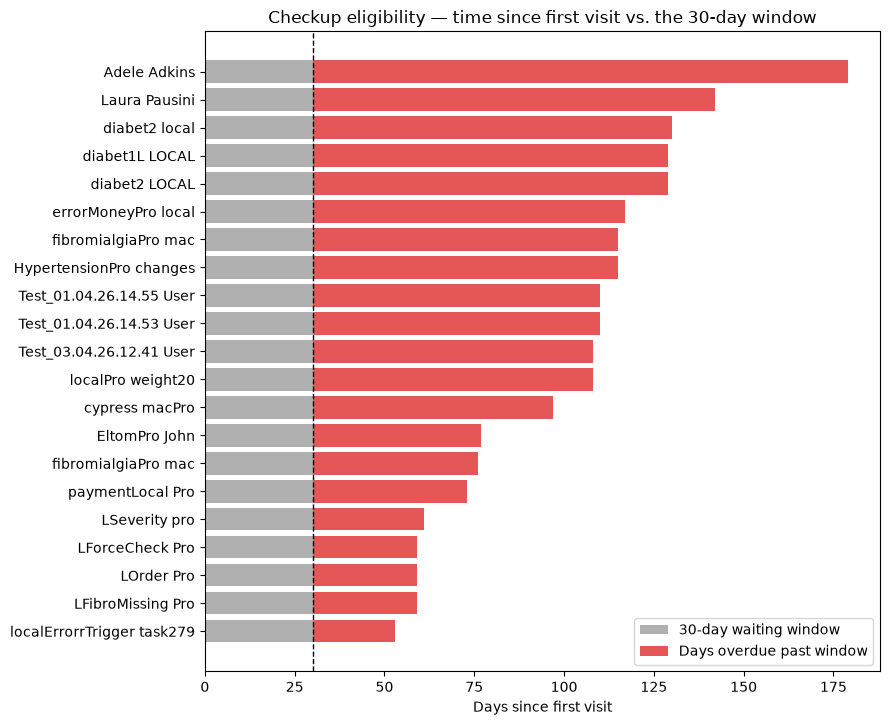

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

WAITING_WINDOW_DAYS = 30

if df.empty:
    print("No clients currently overdue for a checkup.")
else:
    plot_df = df.sort_values("days_since_first_visit").copy()
    plot_df["label"] = plot_df["name"] + " " + plot_df["surname"]
    plot_df["days_overdue"] = plot_df["days_since_first_visit"] - WAITING_WINDOW_DAYS

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(plot_df))))
    y = range(len(plot_df))

    ax.barh(y, [WAITING_WINDOW_DAYS] * len(plot_df), color="#B0B0B0", label="30-day waiting window")
    ax.barh(y, plot_df["days_overdue"], left=WAITING_WINDOW_DAYS, color="#E45756", label="Days overdue past window")

    ax.set_yticks(list(y))
    ax.set_yticklabels(plot_df["label"])
    ax.axvline(WAITING_WINDOW_DAYS, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Days since first visit")
    ax.set_title("Checkup eligibility — time since first visit vs. the 30-day window")
    ax.legend(loc="lower right")
    fig.tight_layout()

    os.makedirs("../assets/img", exist_ok=True)
    fig.savefig("../assets/img/checkup_eligibility.png", dpi=150)
    plt.show()